 سوال 1 و بخش اضافی تمرین

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:


# خواندن داده با pandas
data = pd.read_csv("data.csv")
data = data.dropna()
x = data.drop("Price", axis=1)
y = data["Price"]
x = pd.get_dummies(x, drop_first=True)
# تقسیم داده‌
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# رگرسیون
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'R²: {r2}')


MSE: 681752.3171897923
R²: 0.9914044828589038


بخش اضافی بخش 1

In [ ]:
#Gaussian
from sklearn.kernel_approximation import RBFSampler
# استفاده از RBFSampler برای تبدیل داده‌ها
rbf = RBFSampler(gamma=1.0, n_components=100, random_state=42)
X_train_rbf = rbf.fit_transform(X_train)
X_test_rbf = rbf.transform(X_test)
# مدل رگرسیون خطی
model = LinearRegression()
model.fit(X_train_rbf, y_train)
# پیش‌بینی با مدل
y_pred = model.predict(X_test_rbf)
# محاسبه MSE و R
mse_rbf = mean_squared_error(y_test, y_pred)
r2_rbf = r2_score(y_test, y_pred)
print(f'MSE: {mse_rbf}')
print(f'R²: {r2_rbf}')


MSE: 91999150.10936214
R²: -0.15992311546652327


سوال 2

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# خواندن و پردازش داده‌ها
data = pd.read_csv("data.csv")
data = data.dropna()

X = data.drop("Price", axis=1)
y = data["Price"]

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# تنظیمات آزمایش‌ها
experiments = {
    "Experiment 1": (0.8, 0.1, 0.1),
    "Experiment 2": (0.7, 0.1, 0.2),
    "Experiment 3": (0.6, 0.1, 0.3),
}

# اجرای سه آزمایش مختلف
for exp_name, (train_size, val_size, test_size) in experiments.items():
    print(f"\nejra {exp_name}...")
    
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_size, random_state=42)
    # تقسیم باقی‌مانده به تست و اعتبارسنجی
    val_test_ratio = val_size / (val_size + test_size) 
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1-val_test_ratio, random_state=42)
    print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")
    # ایجاد ویژگی‌های چندجمله‌ای
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    X_test_poly = poly.transform(X_test)

    # مقیاس‌بندی ویژگی‌ها
    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly)
    X_val_poly = scaler.transform(X_val_poly)
    X_test_poly = scaler.transform(X_test_poly)

    print(f"{exp_name} anjam shod.")



ejra Experiment 1...
Train size: 643, Validation size: 80, Test size: 81
Experiment 1 anjam shod.

ejra Experiment 2...
Train size: 562, Validation size: 80, Test size: 162
Experiment 2 anjam shod.

ejra Experiment 3...
Train size: 482, Validation size: 80, Test size: 242
Experiment 3 anjam shod.


In [6]:


from sklearn.metrics import mean_squared_error, r2_score




# تابع گرادیان نزولی با توقف زودهنگام
def gradient_descent_stop(X, y, X_val, y_val, learning_rate=0.01, epochs=1000, patience=10):
    m, n = X.shape
    theta = np.zeros(n)
    best_val_loss = float("inf")
    patience_counter = 0
    
    for epoch in range(epochs):
        gradients = X.T @ (X @ theta - y) / m
        theta = theta - learning_rate * gradients

        val_loss = mean_squared_error(y_val, X_val @ theta)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f" stop  epoch {epoch}")
            break
    
    return theta

#  از اینجا به بعد از کد بالا دوباره کپی کردم چون ارور می خورد
for exp_name, (train_size, val_size, test_size) in experiments.items():
    print(f"\nejra {exp_name}...")

    # تقسیم اولیه: آموزش و باقی‌مانده
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=train_size, random_state=42)
    
    # تقسیم باقی‌مانده به تست و اعتبارسنجی
    val_test_ratio = val_size / (val_size + test_size)  
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1-val_test_ratio, random_state=42)

    print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

    # ایجاد ویژگی‌های چندجمله‌ای
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    X_test_poly = poly.transform(X_test)

    # مقیاس‌بندی ویژگی‌ها
    scaler = StandardScaler()
    X_train_poly = scaler.fit_transform(X_train_poly)
    X_val_poly = scaler.transform(X_val_poly)
    X_test_poly = scaler.transform(X_test_poly)

    theta = gradient_descent_stop(X_train_poly, y_train, X_val_poly, y_val)
    y_pred_train = X_train_poly @ theta
    y_pred_val = X_val_poly @ theta
    y_pred_test = X_test_poly @ theta

    # ارزیابی مدل
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_val = mean_squared_error(y_val, y_pred_val)
    mse_test = mean_squared_error(y_test, y_pred_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_val = r2_score(y_val, y_pred_val)
    r2_test = r2_score(y_test, y_pred_test)

    # نمایش نتایج
    print(f'{exp_name} natayaej:')
    print(f'Train MSE: {mse_train:.4f}, R²: {r2_train:.4f}')
    print(f'Validation MSE: {mse_val:.4f}, R²: {r2_val:.4f}')
    print(f'Test MSE: {mse_test:.4f}, R²: {r2_test:.4f}')



ejra Experiment 1...
Train size: 643, Validation size: 80, Test size: 81
Experiment 1 anjam shod.

ejra Experiment 2...
Train size: 562, Validation size: 80, Test size: 162
Experiment 2 anjam shod.

ejra Experiment 3...
Train size: 482, Validation size: 80, Test size: 242
Experiment 3 anjam shod.

ejra Experiment 1...
Train size: 643, Validation size: 80, Test size: 81
 stop  epoch 13
Experiment 1 natayaej:
Train MSE: 465493209.4196, R²: -3.5630
Validation MSE: 467355088.7340, R²: -4.7425
Test MSE: 460078270.8944, R²: -4.9549

ejra Experiment 2...
Train size: 562, Validation size: 80, Test size: 162
Experiment 2 natayaej:
Train MSE: 459031568.0685, R²: -3.5614
Validation MSE: 459225629.9950, R²: -4.7425
Test MSE: 459238350.6728, R²: -3.8023

ejra Experiment 3...
Train size: 482, Validation size: 80, Test size: 242
 stop  epoch 110
Experiment 3 natayaej:
Train MSE: 462454033.7308, R²: -3.4047
Validation MSE: 467607225.3805, R²: -3.2411
Test MSE: 462900068.8152, R²: -5.0484


سوال 3

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# بارگذاری داده‌ها
features = pd.read_csv('features.txt')
labels = pd.read_csv('labels.txt')

X = features.values
y = labels.values

# افزودن ستون بایاس به داده‌ها
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# پیاده‌سازی رگرسیون خطی ساده
def linear_regression(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

# به دست آوردن پارامترهای مدل
w_simple = linear_regression(X_b, y)

# پیاده‌سازی رگرسیون خطی وزن‌دار
def linear_regression_vazn_dar(X, y, weights):
    W = np.diag(weights)
    return np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y

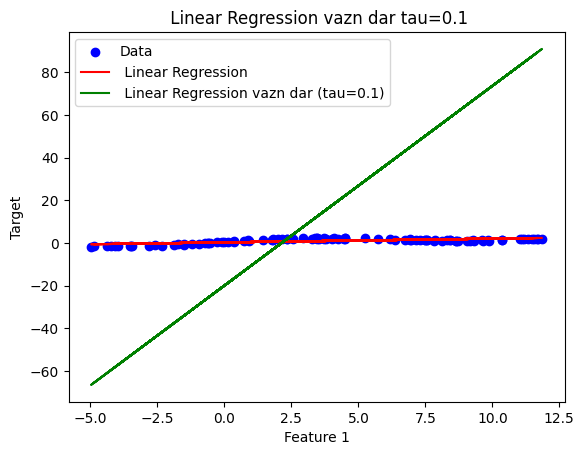

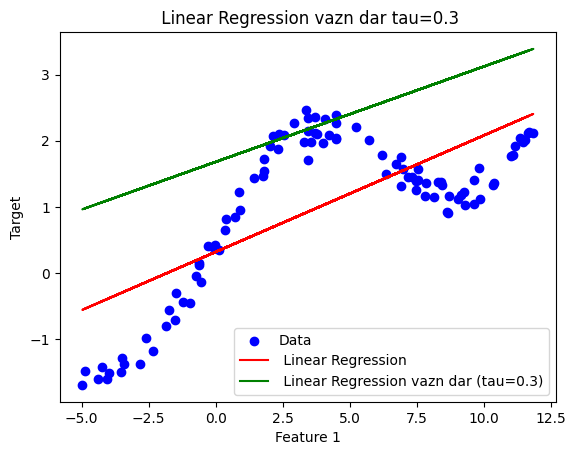

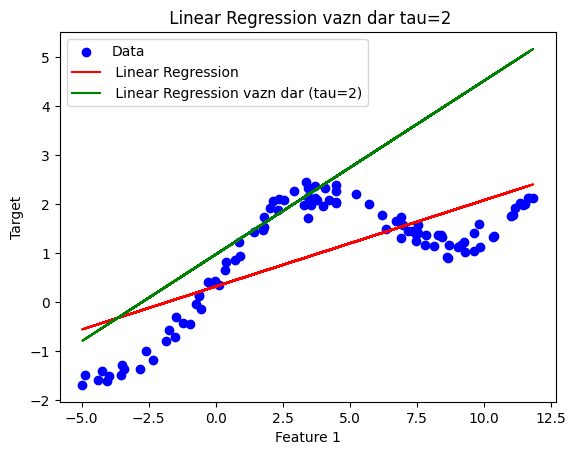

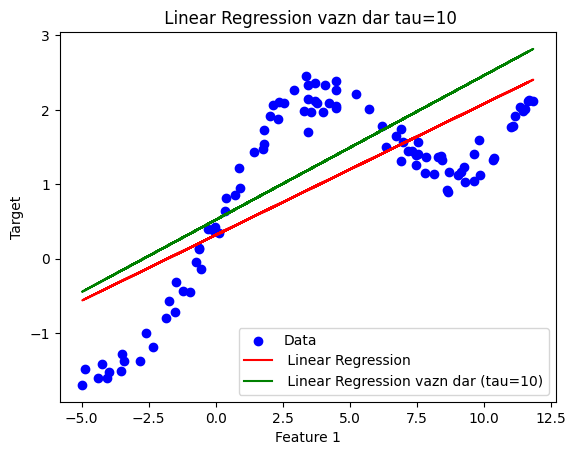

In [6]:


# انتخاب وزن‌ها بر اساس فرمول داده‌شده
def mohasebe_weight(X, x_ref, tau):
    return np.exp(-2 * np.linalg.norm(X - x_ref, axis=1)**2 / tau**2)

# به دست آوردن پارامترهای مدل با وزن‌ها
x_ref = X[0]  
tau_values = [0.1, 0.3, 2, 10]

for tau in tau_values:
    weights = mohasebe_weight(X, x_ref, tau)
    w_weighted = linear_regression_vazn_dar(X_b, y, weights)
    
    # رسم نمودار
    plt.figure()
    
    # استفاده از ویژگی اول برای رسم
    plt.scatter(X[:, 0], y, color='blue', label='Data')  
    plt.plot(X[:, 0], X_b @ w_simple, color='red', label=' Linear Regression')
    plt.plot(X[:, 0], X_b @ w_weighted, color='green', label=f' Linear Regression vazn dar (tau={tau})')
    
    plt.xlabel('Feature 1') 
    plt.ylabel('Target')
    plt.legend()
    plt.title(f' Linear Regression vazn dar tau={tau}')
    plt.show()


سوال 4

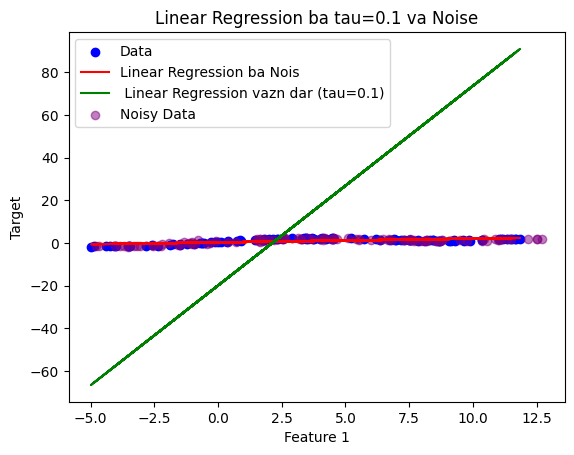

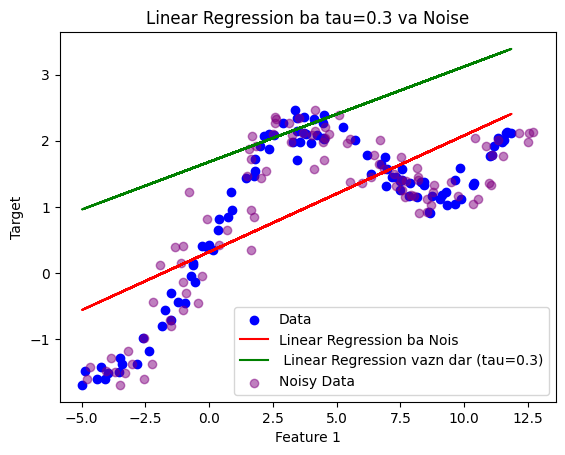

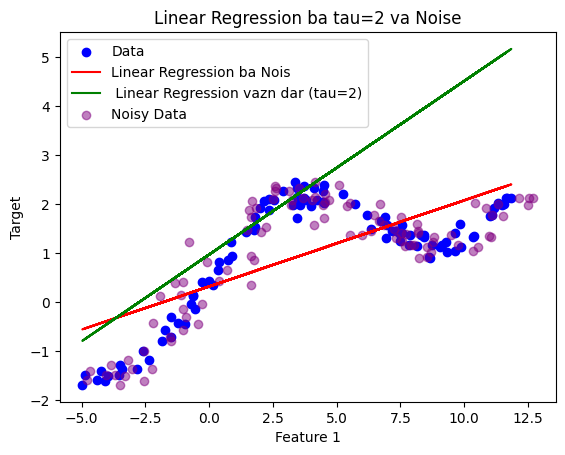

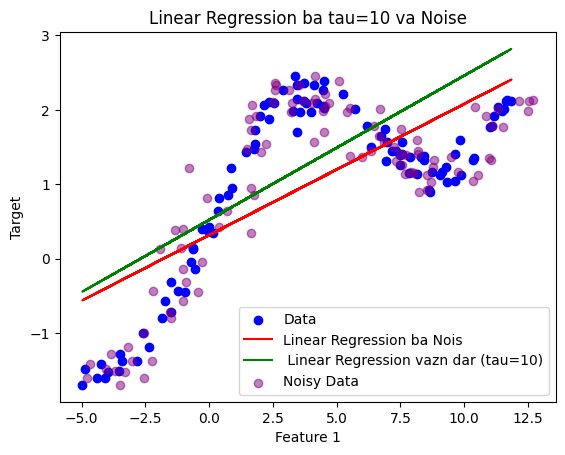

In [11]:



# افزودن نویز به داده‌ها
def add_noise(X, sigma=1.0):
    noise = np.random.normal(0, sigma, X.shape)
    return X + noise

# به دست آوردن پارامترهای مدل
x_ref = X[0] 
tau_values = [0.1, 0.3, 2, 10]
sigma = 1.0  

# اضافه کردن نویز به داده‌های ورودی
X_noisy = add_noise(X, sigma)

# رسم رگرسیون خطی برای هر مقدار tau
for tau in tau_values:
    weights = mohasebe_weight(X, x_ref, tau)
    w_simple = linear_regression(X_b, y)
    w_weighted = linear_regression_vazn_dar(X_b, y, weights)
    plt.figure()

    # استفاده از ویژگی اول برای رسم
    plt.scatter(X[:, 0], y, color='blue', label='Data')  
    plt.plot(X[:, 0], X_b @ w_simple, color='red', label='Linear Regression ba Nois')
    plt.plot(X[:, 0], X_b @ w_weighted, color='green', label=f' Linear Regression vazn dar (tau={tau})')
    
    # رسم برای داده‌های نویزی
    plt.scatter(X_noisy[:, 0], y, color='purple', label='Noisy Data', alpha=0.5)
    plt.xlabel('Feature 1') 
    plt.ylabel('Target')
    plt.legend()
    plt.title(f'Linear Regression ba tau={tau} va Noise')
    plt.show()


سوال 5

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:


np.random.seed(42)
tedad_group = 20  
tedad_dansh_amoz = 10  
w0 = 5  
w1 = 2  
sigma_u = 2 
sigma_e = 1  

# تولید  تصادفی برای هر گروه
group_effects = np.random.normal(0, sigma_u, tedad_group)

data = []
for j in range(tedad_group):
    x = np.random.uniform(0, 20, tedad_dansh_amoz)  
    y = w0 + w1 * x + group_effects[j] + np.random.normal(0, sigma_e, tedad_dansh_amoz)
    group = [j] * tedad_dansh_amoz
    data.append(pd.DataFrame({'group': group, 'x': x, 'y': y}))

df = pd.concat(data).reset_index(drop=True)



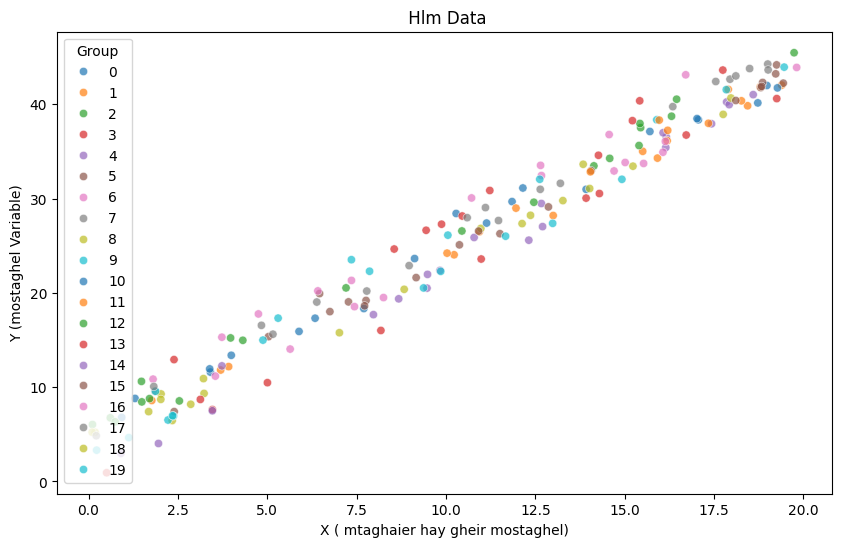

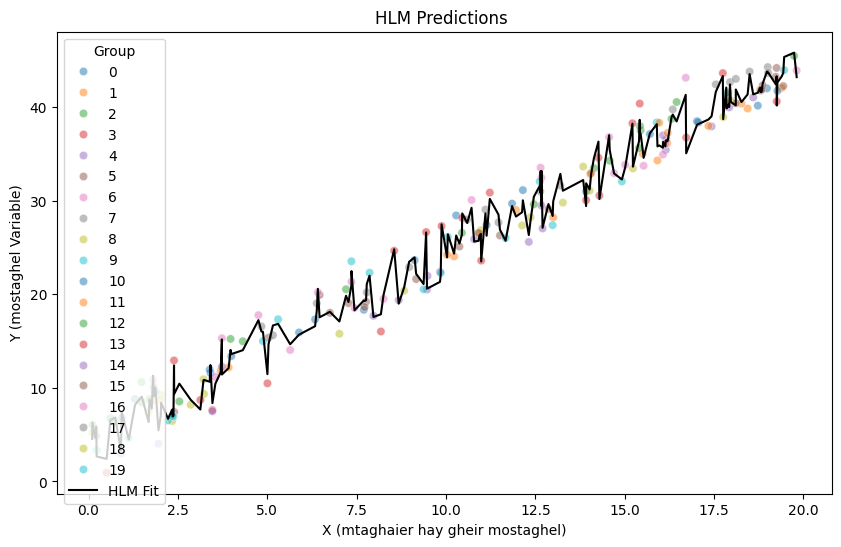

In [6]:
#Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(x='x', y='y', hue='group', data=df, palette='tab10', alpha=0.7)
plt.xlabel('X ( mtaghaier hay gheir mostaghel)')
plt.ylabel('Y (mostaghel Variable)')
plt.title(' Hlm Data')
plt.legend(title='Group')
plt.show()

#  Hierarchical Linear Model 
model = smf.mixedlm("y ~ x", df, groups=df["group"])
result = model.fit()
df['predicted'] = result.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x='x', y='y', hue='group', data=df, palette='tab10', alpha=0.5)
sns.lineplot(x='x', y='predicted', data=df, color='black', label='HLM Fit')
plt.xlabel('X (mtaghaier hay gheir mostaghel)')
plt.ylabel('Y (mostaghel Variable)')
plt.title('HLM Predictions ')
plt.legend(title='Group')
plt.show()


سوال6

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
#یکی از کتابخانه های است که برای جریمه کردن رگرسیون استقاده می شود
from scipy.interpolate import LSQUnivariateSpline

In [16]:
# خواندن داده‌ها و می توان به جای ایکس هر فیچر دیگه ای قرار بدهیم
data = pd.read_csv("data.csv").dropna()
X = data["Mileage"].values  
y = data["Price"].values

# تقسیم داده‌ها به 70% آموزش و 30% تست طبق سوال
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# مرتب‌سازی داده‌های آموزشی برای اینکه ارور می گرفت 
sorted_indices = np.argsort(X_train)
X_train_sorted = X_train[sorted_indices]
y_train_sorted = y_train[sorted_indices]

# مدل رگرسیون خطی
lin_reg = LinearRegression()
lin_reg.fit(X_train_sorted.reshape(-1, 1), y_train_sorted)
y_pred_linear = lin_reg.predict(X_test.reshape(-1, 1))
mse_linear = mean_squared_error(y_test, y_pred_linear)

# بررسی تاثیر تعداد گره‌ها بر عملکرد Penalized Spline
knots_list = [2, 3, 5, 7, 10]  
mse_spline_list = []

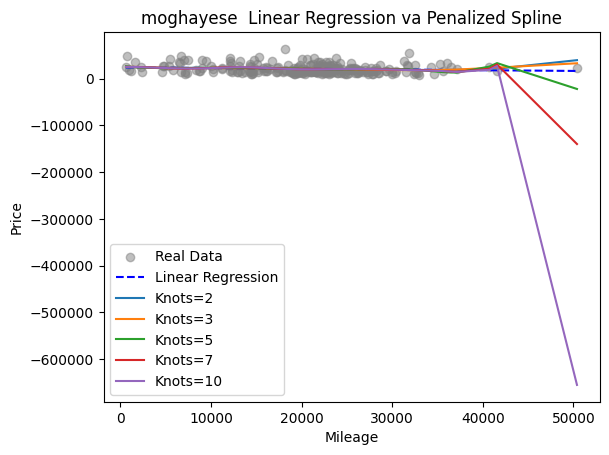

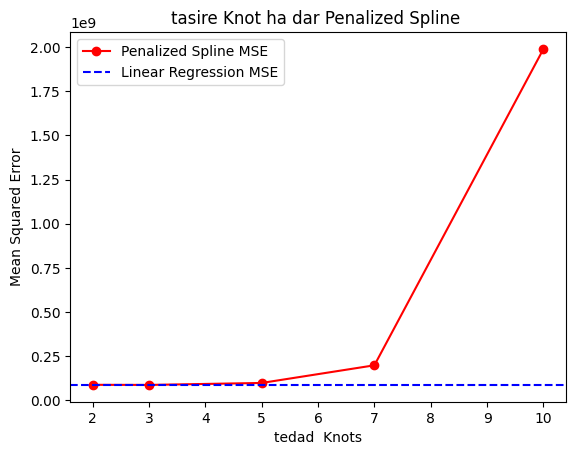

MSE - Linear Regression: 87639036.4385
MSE - Penalized Spline (Knots=2): 88540430.5519
MSE - Penalized Spline (Knots=3): 87904730.1167
MSE - Penalized Spline (Knots=5): 99043321.6686
MSE - Penalized Spline (Knots=7): 198952891.7774
MSE - Penalized Spline (Knots=10): 1989807027.6364


In [ ]:




# نمایش داده‌های واقعی
plt.scatter(X_test, y_test, label="Real Data", color='gray', alpha=0.5)
plt.plot(np.sort(X_test), lin_reg.predict(np.sort(X_test).reshape(-1, 1)), label="Linear Regression", color='blue', linestyle='dashed')

# Penalized Spline برای گره‌های مختلف
for num_knots in knots_list:
    knots = np.linspace(X_train_sorted.min(), X_train_sorted.max(), num_knots+2)[1:-1] 
    spline = LSQUnivariateSpline(X_train_sorted, y_train_sorted, knots, k=3)  

    y_pred_spline = spline(X_test)
    mse_spline = mean_squared_error(y_test, y_pred_spline)
    mse_spline_list.append(mse_spline)
    
    plt.plot(np.sort(X_test), spline(np.sort(X_test)), label=f"Knots={num_knots}")

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("moghayese  Linear Regression va Penalized Spline")
plt.legend()
plt.show()

# رسم نمودار خطای Penalized Spline در مقابل تعداد گره‌ها
plt.plot(knots_list, mse_spline_list, marker='o', linestyle='-', color='red', label="Penalized Spline MSE")
plt.axhline(y=mse_linear, color='blue', linestyle='dashed', label="Linear Regression MSE")
plt.xlabel("tedad  Knots")
plt.ylabel("Mean Squared Error")
plt.title("tasire Knot ha dar Penalized Spline ")
plt.legend()
plt.show()
print(f"MSE - Linear Regression: {mse_linear:.4f}")
for i, num_knots in enumerate(knots_list):
    print(f"MSE - Penalized Spline (Knots={num_knots}): {mse_spline_list[i]:.4f}")
